# Autofit tool for aligning data with the modes

`pyMMF.tools.autofit` allows for finding the transformation to center the fiber axis and the zoom to fit the simulated modes.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



import os, sys
print(os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))af.getTransformationMatrix(params=params, n_points=N)
# sys.path.insert(0, os.path.abspath('..'))


import pyMMF
print(pyMMF.__path__)
from pyMMF.functions import colorize
from pyMMF.tools.autofit import Autofit

/home/spopoff/mycore/dev/pyMMF
['/home/spopoff/mycore/dev/pyMMF/pyMMF']


## 1. Fiber parameters

In [2]:
NA = 0.2
radius = 25 # in microns
areaSize = 3.*radius # calculate the field on an area larger than the diameter of the fiber
n_points_modes = 48 # resolution of the window2
n1 = 1.45 # index of refraction at r=0 (maximum)
wl = 1.55 # wavelength in microns
curvature = None
k0 = 2.*np.pi/wl

r_max = 3.2*radius
npoints_search = 2**8
dh = 2*radius/npoints_search

# solver parameters
solver_options = {
    'degenerate_mode': 'exp', # 'eig' or 'prop'
    'min_radius_bc': 1.5,   # min large radial boundary condition
    'N_beta_coarse': 1_000, # number of steps of the initial coarse scan
    'change_bc_radius_step': 0.95, #change of the large radial boundary condition if fails 
    'dh': dh,               # radial resolution during the computation
    'r_max': r_max,         # max radius to calculate (and first try for large radial boundary condition)
}

## 2. Compute the mode with radial solver

In [3]:
profile = pyMMF.IndexProfile(
    npoints = n_points_modes, 
    areaSize = areaSize
)
profile.initParabolicGRIN(n1=n1, a=radius, NA=NA)

solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)


modes = solver.solve(solver='radial',
                    curvature = curvature,
                    options = solver_options
                    )


2025-10-14 16:52:46,670 - pyMMF.core [DEBUG  ]  Debug mode ON.
2025-10-14 16:52:46,670 - pyMMF.solv [INFO   ]  Searching for modes with beta_min=5.821637357564584, beta_max=5.877818513168
2025-10-14 16:52:46,683 - pyMMF.solv [INFO   ]  Found 5 radial mode(s) for m=0
2025-10-14 16:52:46,684 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2025-10-14 16:52:46,685 - pyMMF.solv [ERROR  ]  Field limit 1.0 at the founded beta=0.05066217542815342 is greater than field_limit_tol=0.001
2025-10-14 16:52:46,685 - pyMMF.solv [WARNING]  Boundary condition could not be met.
2025-10-14 16:52:46,686 - pyMMF.solv [WARNING]  Retrying by changing r_max to 3.04a
2025-10-14 16:52:46,686 - pyMMF.solv [ERROR  ]  Field limit 1.0 at the founded beta=0.05066217542815342 is greater than field_limit_tol=0.001
2025-10-14 16:52:46,687 - pyMMF.solv [WARNING]  Boundary condition could not be met.
2025-10-14 16:52:46,687 - pyMMF.solv [WARNING]  Retrying by changing r_max to 2.89a
2025-10-14 16:52:46,

## 3. Simulating the shift/zoom of the data by applying a transformation of the modes

In [ ]:
M0 = modes.getModeMatrix()

af = Autofit(modes)

TM_mode_basis = modes.getPropagationMatrix(1e4) # propagation of 1 cm

TM_0 = M0 @ TM_mode_basis @ M0.conj().T

# Use explicit params (list)
params = [1.15, (2., 3.), (-4., 3.)]
TM_misaligned = af.transform(TM_0, params=params)

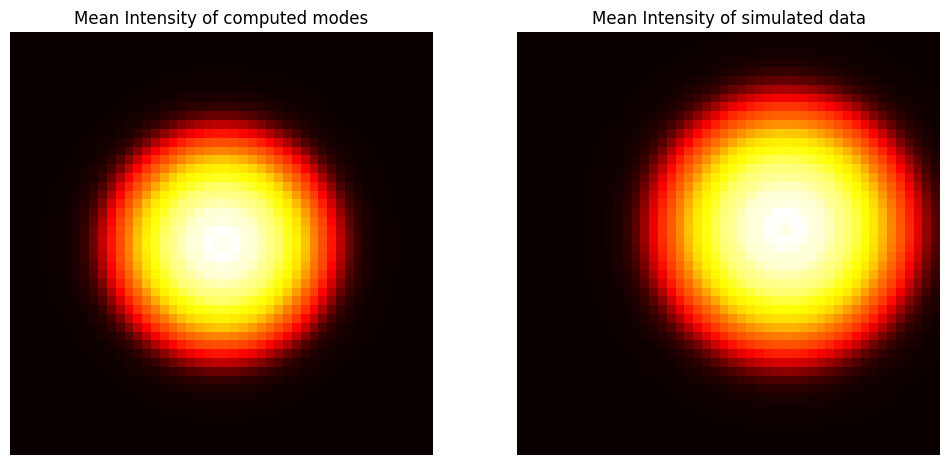

In [6]:
N = modes.indexProfile.npoints
M0 = modes.getModeMatrix()



# compute average output intensity 
mean_I0 = np.mean(np.abs(TM_0)**2, axis=1).reshape((N, N))
mean_I1 = np.mean(np.abs(TM_misaligned)**2, axis=1).reshape((N, N))

plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(mean_I0, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity of computed modes')
plt.subplot(1,2,2)
plt.imshow(mean_I1, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity of simulated data')
plt.show()

## 4. Autofit to find the transformation to recenter/rezoom the data

Text(0.5, 1.0, 'Mean Intensity after transformation')

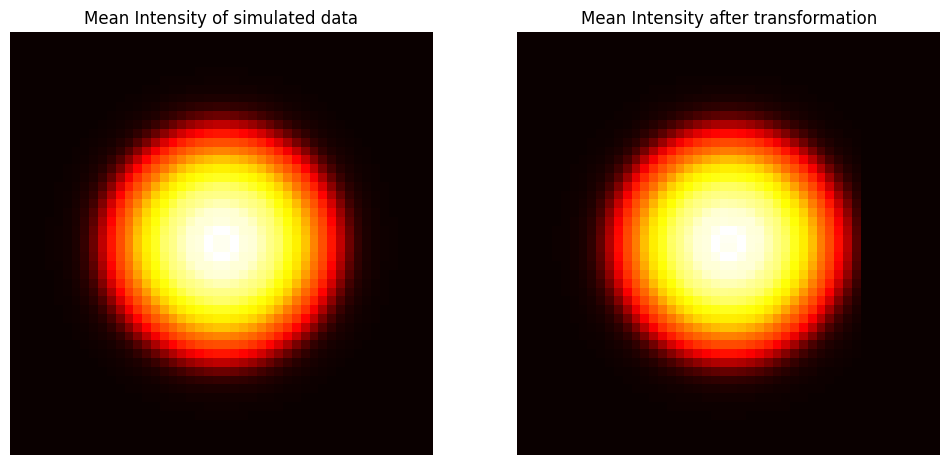

In [ ]:
fit = Autofit(modes)
fit.fit_to_data(mean_I1)
TM_realigned = fit.transform(TM_misaligned)

                            
I_realigned = np.sum(np.abs(TM_realigned)**2, axis=1).reshape((N, N))


plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(mean_I0, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity of simulated data')
plt.subplot(1,2,2)
plt.imshow(I_realigned, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity after transformation')



Computation effiency of the projection of the TM onto the mode basis

We compute the ratio of the energy of the TM after projection in the mode basis with the one of the initial TM.
If we have the right modes, and the zoom/shift is compensated for, it should be equal to 1.

In [8]:
conversion_efficiency_before =  np.linalg.norm(M0.conj().T @ TM_misaligned @ M0)/np.linalg.norm(TM_misaligned)
conversion_efficiency_after =  np.linalg.norm(M0.conj().T @ TM_realigned @ M0)/np.linalg.norm(TM_realigned)

print(f"Conversion efficiency before: {conversion_efficiency_before:.6f}, after: {conversion_efficiency_after:.6f}")

Conversion efficiency before: 0.811440, after: 0.997533
